# QAOA for Maximum Cut
## Part VII: Experiments — QAOA Quantum circuit and measurement

**Physics 565/656 · Spring 2026 · Sehong Park and Adolfo Menendez Rua**

This notebook implements the QAOA Quantum Circuit for different values of p on three graph instances with distinct structural properties.

**Graphs:** $C_{10}$, $C_{10}$ + 3 chords, 3-regular ($n=10$)  
**Methods:**  QAOA $p=1,2,3$


---
## 1. Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cvxpy as cp
from scipy.optimize import minimize
import warnings
import qiskit
warnings.filterwarnings('ignore')

MASTER_SEED = 42
np.random.seed(MASTER_SEED)

# ── Core utilities ─────────────────────────────────────────────────
def cut_val(bits, edges):
    return sum(1 for i,j in edges if bits[i] != bits[j])

def exact_maxcut(edges, n):
    """Brute-force exact MaxCut (n ≤ 20)."""
    best = 0
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        best = max(best, cut_val(bits, edges))
    return best

print("Setup complete.")


Setup complete.


---
## 2. Graph Instances

| Graph | Structure | Role |
|-------|-----------|------|
| $C_{10}$ | 10-cycle | Sanity check; QAOA theoretically analyzed (2-regular) |
| $C_{10}$ + 3 chords | Cycle + long-range edges | Local structure disrupted; greedy struggles |
| 3-regular ($n=10$) | All degrees = 3 | Directly analyzed in Farhi et al. (2014) |

These three instances represent distinct structural regimes: a 2-regular cycle (analytically tractable), a cycle with long-range edges (disrupted locality), and a 3-regular graph (studied directly in Farhi et al. 2014).


In [2]:
n = 10

# ── C10 ──────────────────────────────────────────────────────────
G1 = nx.cycle_graph(n)
e1 = list(G1.edges())

# ── C10 + 3 chords ───────────────────────────────────────────────
G2 = nx.cycle_graph(n)
non_edges = [(i,j) for i in range(n) for j in range(i+2, n)
             if abs(i-j) > 1 and not (i == 0 and j == n-1)]
chord_idx = np.random.default_rng(0).choice(len(non_edges), size=3, replace=False)
CHORDS = [non_edges[c] for c in chord_idx]
for c in CHORDS:
    G2.add_edge(*c)
e2 = list(G2.edges())

# ── 3-regular n=10 ───────────────────────────────────────────────
G3 = nx.random_regular_graph(3, n, seed=7)
e3 = list(G3.edges())

GRAPHS = [
    (r'$C_{10}$',            G1, e1),
    (r'$C_{10}$ + 3 chords', G2, e2),
    (r'3-regular ($n=10$)',   G3, e3),
]

for name, G, edges in GRAPHS:
    opt = exact_maxcut(edges, n)
    print(f"{name}: |E|={len(edges)}, OPT={opt}, avg_degree={2*len(edges)/n:.1f}")
print(f"Chords added to G2: {CHORDS}")


$C_{10}$: |E|=10, OPT=10, avg_degree=2.0
$C_{10}$ + 3 chords: |E|=13, OPT=13, avg_degree=2.6
3-regular ($n=10$): |E|=15, OPT=13, avg_degree=3.0
Chords added to G2: [(3, 6), (2, 7), (4, 9)]


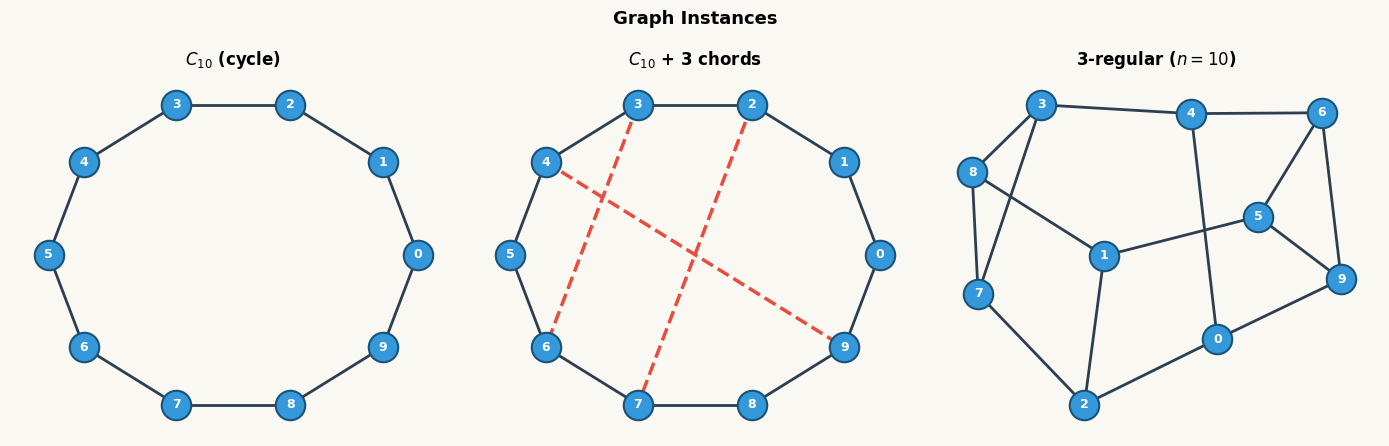

In [3]:
# ── Visualize ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor("#FAF8F3")  # <-- bckg color
titles = [r'$C_{10}$ (cycle)', r'$C_{10}$ + 3 chords', r'3-regular ($n=10$)']

for ax, (name, G, edges), title in zip(axes, GRAPHS, titles):
    pos = nx.circular_layout(G) if G in [G1, G2] else nx.spring_layout(G, seed=MASTER_SEED)

    if G is G2:
        cycle_e = list(nx.cycle_graph(n).edges())
        chord_e = [e for e in G.edges()
                   if e not in cycle_e and (e[1],e[0]) not in cycle_e]
        nx.draw_networkx_edges(G, pos, edgelist=cycle_e, ax=ax,
                               edge_color='#2C3E50', width=2)
        nx.draw_networkx_edges(G, pos, edgelist=chord_e, ax=ax,
                               edge_color='#E74C3C', width=2.5, style='dashed')
        # chord_patch = plt.Line2D([0],[0], color='#E74C3C', lw=2, ls='--', label='Chords')
        # cycle_patch = plt.Line2D([0],[0], color='#2C3E50', lw=2, label='Cycle')
        # ax.legend(handles=[cycle_patch, chord_patch], fontsize=8, loc='upper right')
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#2C3E50', width=2)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#3498DB',
                           node_size=450, edgecolors='#1A5276', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_size=9, font_weight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Graph Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_graphs.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 3. QAOA Statevector Simulation

**Cost unitary** $U_C(\gamma) = e^{-i\gamma H_C}$:
diagonal phase oracle, $O(2^n)$ in simulation, $O(|E|)$ circuit depth on hardware.

**Mixer unitary** $U_B(\beta) = \bigotimes_i e^{-i\beta X_i}$:
separable, applied qubit by qubit.

**Optimizer:** COBYLA with 20 random restarts to avoid local minima.


In [4]:
# ── QAOA engine ──────────────────────────────────────────────────
def build_diag(edges, n):
    """Diagonal of H_C in the computational basis."""
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        d[x] = cut_val(bits, edges)
    return d

def apply_UB(psi, beta, n):
    """Apply mixer e^{-iβ H_B} qubit by qubit (separable: O(n·2^n))."""
    c, s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,q,0).reshape(2,-1)
        psi = np.array([c*psi[0]-1j*s*psi[1], -1j*s*psi[0]+c*psi[1]])
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,0,q)
    return psi.reshape(-1)

def run_qaoa(edges, n, p, n_restarts=20):
    """
    QAOA for MaxCut. Returns (best_ratio, best_params).
    Maximizes F_p = <psi_p | H_C | psi_p> via COBYLA.
    """
    diag = build_diag(edges, n)
    OPT  = int(round(diag.max()))
    DIM  = 2**n

    def energy(theta):
        g = theta[:p]; b = theta[p:]
        psi = np.ones(DIM, dtype=complex) / np.sqrt(DIM)
        for k in range(p):
            psi = np.exp(-1j * g[k] * diag) * psi
            psi = apply_UB(psi, b[k], n)
        return -np.real(np.dot(psi.conj(), diag * psi))

    best = None
    for t in range(n_restarts):
        rng = np.random.default_rng(MASTER_SEED + t * 7)
        theta0 = rng.uniform(0, np.pi/2, 2*p)
        res = minimize(energy, theta0, method='COBYLA',
                       options={'maxiter': 800, 'rhobeg': 0.5})
        if best is None or res.fun < best.fun:
            best = res

    return -best.fun / OPT, best.x

# Sanity check: C4, p=1 should give ratio = 0.7500
ratio_c4, bestparams = run_qaoa([(0,1),(1,2),(2,3),(0,3)], 4, p=1)
print(bestparams)
print(f"Sanity check — C4, p=1: ratio = {ratio_c4:.6f}  (expected: 0.750000)")


[2.3561565  1.17810405]
Sanity check — C4, p=1: ratio = 0.750000  (expected: 0.750000)


---
## 4. QAOA Statevector Simulation

**Cost unitary** $U_C(\gamma) = e^{-i\gamma H_C}$:
diagonal phase oracle, $O(2^n)$ in simulation, $O(|E|)$ circuit depth on hardware.

**Mixer unitary** $U_B(\beta) = \bigotimes_i e^{-i\beta X_i}$:
separable, applied qubit by qubit.

**Optimizer:** COBYLA with 20 random restarts to avoid local minima.


In [31]:
# ── QAOA engine ──────────────────────────────────────────────────
def build_diag(edges, n):
    """Diagonal of H_C in the computational basis."""
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        d[x] = cut_val(bits, edges)
    return d

def apply_UB(psi, beta, n):
    """Apply mixer e^{-iβ H_B} qubit by qubit (separable: O(n·2^n))."""
    c, s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,q,0).reshape(2,-1)
        psi = np.array([c*psi[0]-1j*s*psi[1], -1j*s*psi[0]+c*psi[1]])
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,0,q)
    return psi.reshape(-1)

def run_qaoa(edges, n, p, n_restarts=20):
    """
    QAOA for MaxCut. Returns (best_ratio, best_params).
    Maximizes F_p = <psi_p | H_C | psi_p> via COBYLA.
    """
    diag = build_diag(edges, n)
    OPT  = int(round(diag.max()))
    DIM  = 2**n

    def energy(theta):
        g = theta[:p]; b = theta[p:]
        psi = np.ones(DIM, dtype=complex) / np.sqrt(DIM)
        for k in range(p):
            psi = np.exp(-1j * g[k] * diag) * psi
            psi = apply_UB(psi, b[k], n)
        return -np.real(np.dot(psi.conj(), diag * psi))

    best = None
    for t in range(n_restarts):
        rng = np.random.default_rng(MASTER_SEED + t * 7)
        theta0 = rng.uniform(0, np.pi/2, 2*p)
        res = minimize(energy, theta0, method='COBYLA',
                       options={'maxiter': 800, 'rhobeg': 0.5})
        if best is None or res.fun < best.fun:
            best = res

    return -best.fun / OPT, best.x

# Run QAOA for all graphs and p=1,2,3
results = {}
for name, G, edges in GRAPHS:
    opt = exact_maxcut(edges, n)
    qaoa = {}
    for p in [1,2,3]:
        ratio, params = run_qaoa(edges, n, p)
        qaoa[p] = ratio
        print(f"QAOA results p = {p}:")
        print(f"{name}: OPT={opt}, QAOA ratios: {ratio}, params: {params}")
    results[name] = {
        "optimal": opt,
        "qaoa": qaoa,
        "params": params
    }


QAOA results p = 1:
$C_{10}$: OPT=10, QAOA ratios: 0.7499999997003828, params: [0.78541572 1.96350394]
QAOA results p = 2:
$C_{10}$: OPT=10, QAOA ratios: 0.8333333326738867, params: [0.65588388 1.24287264 0.62143985 1.8987511 ]
QAOA results p = 3:
$C_{10}$: OPT=10, QAOA ratios: 0.8749999242444584, params: [0.59174325 1.15570715 1.36422747 2.2529987  2.1487362  1.86680204]
QAOA results p = 1:
$C_{10}$ + 3 chords: OPT=13, QAOA ratios: 0.7069733630893336, params: [0.66307551 1.96351358]
QAOA results p = 2:
$C_{10}$ + 3 chords: OPT=13, QAOA ratios: 0.791260315360806, params: [0.50629042 0.92356743 2.1448779  0.32404651]
QAOA results p = 3:
$C_{10}$ + 3 chords: OPT=13, QAOA ratios: 0.8717898887496917, params: [0.48543682 0.80168693 0.94617942 0.64645445 2.1271057  1.90657172]
QAOA results p = 1:
3-regular ($n=10$): OPT=13, QAOA ratios: 0.7752552120944388, params: [0.58822135 1.93587404]
QAOA results p = 2:
3-regular ($n=10$): OPT=13, QAOA ratios: 0.8510313426286833, params: [ 2.63326995 -0.

---
## 5. QAOA Circuit simulation

**Library: qiskit**

### $C_{10}$ , p = 1

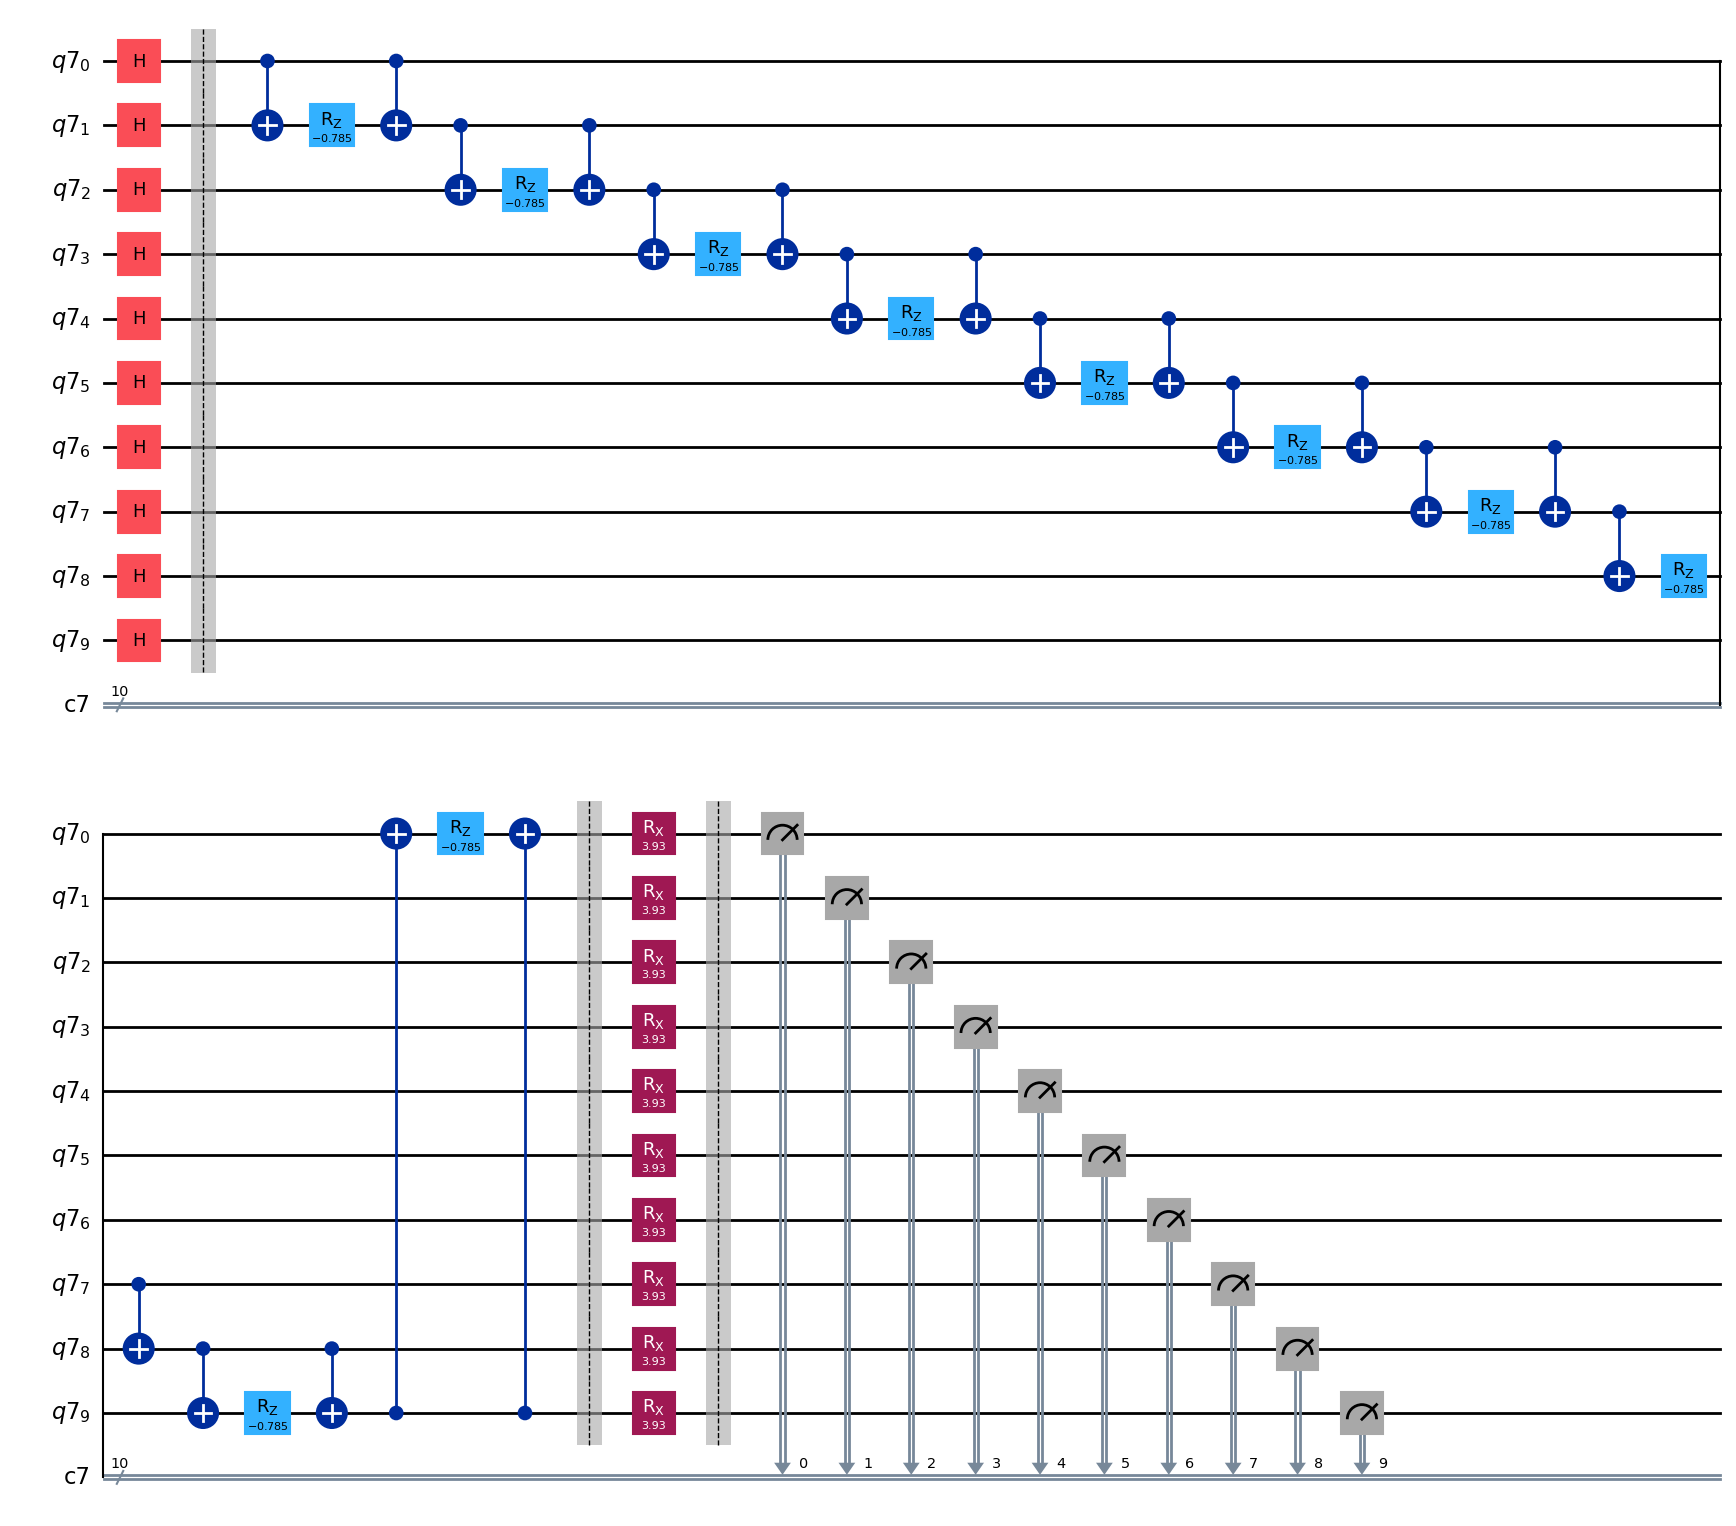

In [32]:
# Create the quantum circuit for C10, p=1
from qiskit import *
from qiskit.visualization import plot_histogram

# Classical pre-optimal parameters for C10, p=1 (from the previous optimization step)
bestparams = [0.78541572, 1.96350394]  # g[0], b[0]

# create 10 quantum registers, one for each qubit
q = QuantumRegister(10)
# create 10 corresponding classical registers (needed for storing measurement results)
c=ClassicalRegister(10)
# create a quantum circuit with these registers
qaoa_qc = QuantumCircuit(q,c)

# Apply Hadamard gates to all qubits to create the initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10
edges_c10 = [(i, (i+1) % 10) for i in range(10)]
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])  # g[0] is the first parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B
for i in range(10):
    qaoa_qc.rx(2 * bestparams[1], q[i])  # b[0] is the second parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Measure all qubits
qaoa_qc.measure(q, c)

# Visualize the circuit
qaoa_qc.draw(output='mpl', style='iqx')


{'0101010010': 62, '1110010101': 2, '0101001010': 79, '1010101010': 961, '1010010010': 89, '0010010101': 79, '0101001001': 76, '1010100100': 87, '0101010101': 961, '0101001100': 2, '1010101100': 44, '0110101010': 59, '1101001010': 108, '0101101010': 95, '1010010100': 74, '0101011011': 88, '0110101011': 80, '0101010011': 56, '1010100101': 97, '1001101010': 53, '0011000101': 3, '0101001011': 103, '0101011010': 111, '0110100101': 113, '0010100101': 76, '0101010110': 56, '1101010010': 87, '1010110110': 65, '1101101010': 91, '0110110101': 85, '1101010101': 6, '1011001010': 51, '1101010110': 78, '1100011010': 3, '0100100101': 71, '1101011010': 88, '1010100110': 44, '1001010100': 88, '1011011010': 76, '0101001101': 46, '0100101011': 101, '0110101001': 109, '1001011010': 100, '1001101100': 3, '1010110010': 57, '0010110101': 116, '1010110100': 94, '0100110101': 55, '0010101001': 81, '0010101101': 107, '1101010100': 57, '1001010110': 121, '0010101011': 56, '0110010101': 49, '1010100010': 11, '01

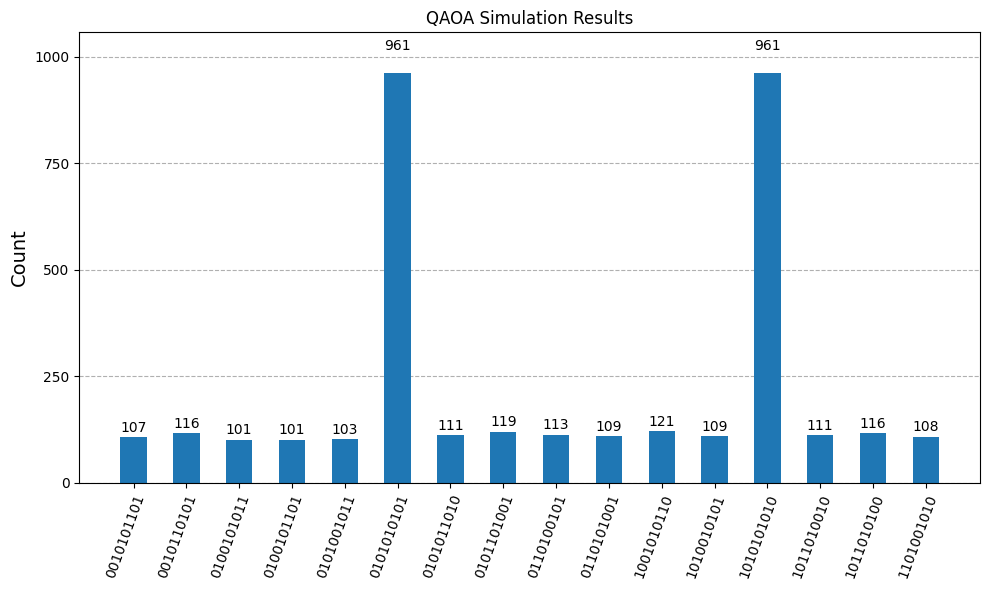

In [47]:
# ── Run simulation ───────────────────────────────────────────────

from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

backend = AerSimulator()
sampler = AerSampler()

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_1 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_1.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_1, figsize=(10,6), title="QAOA Simulation Results")

### $C_{10}$ , p = 2

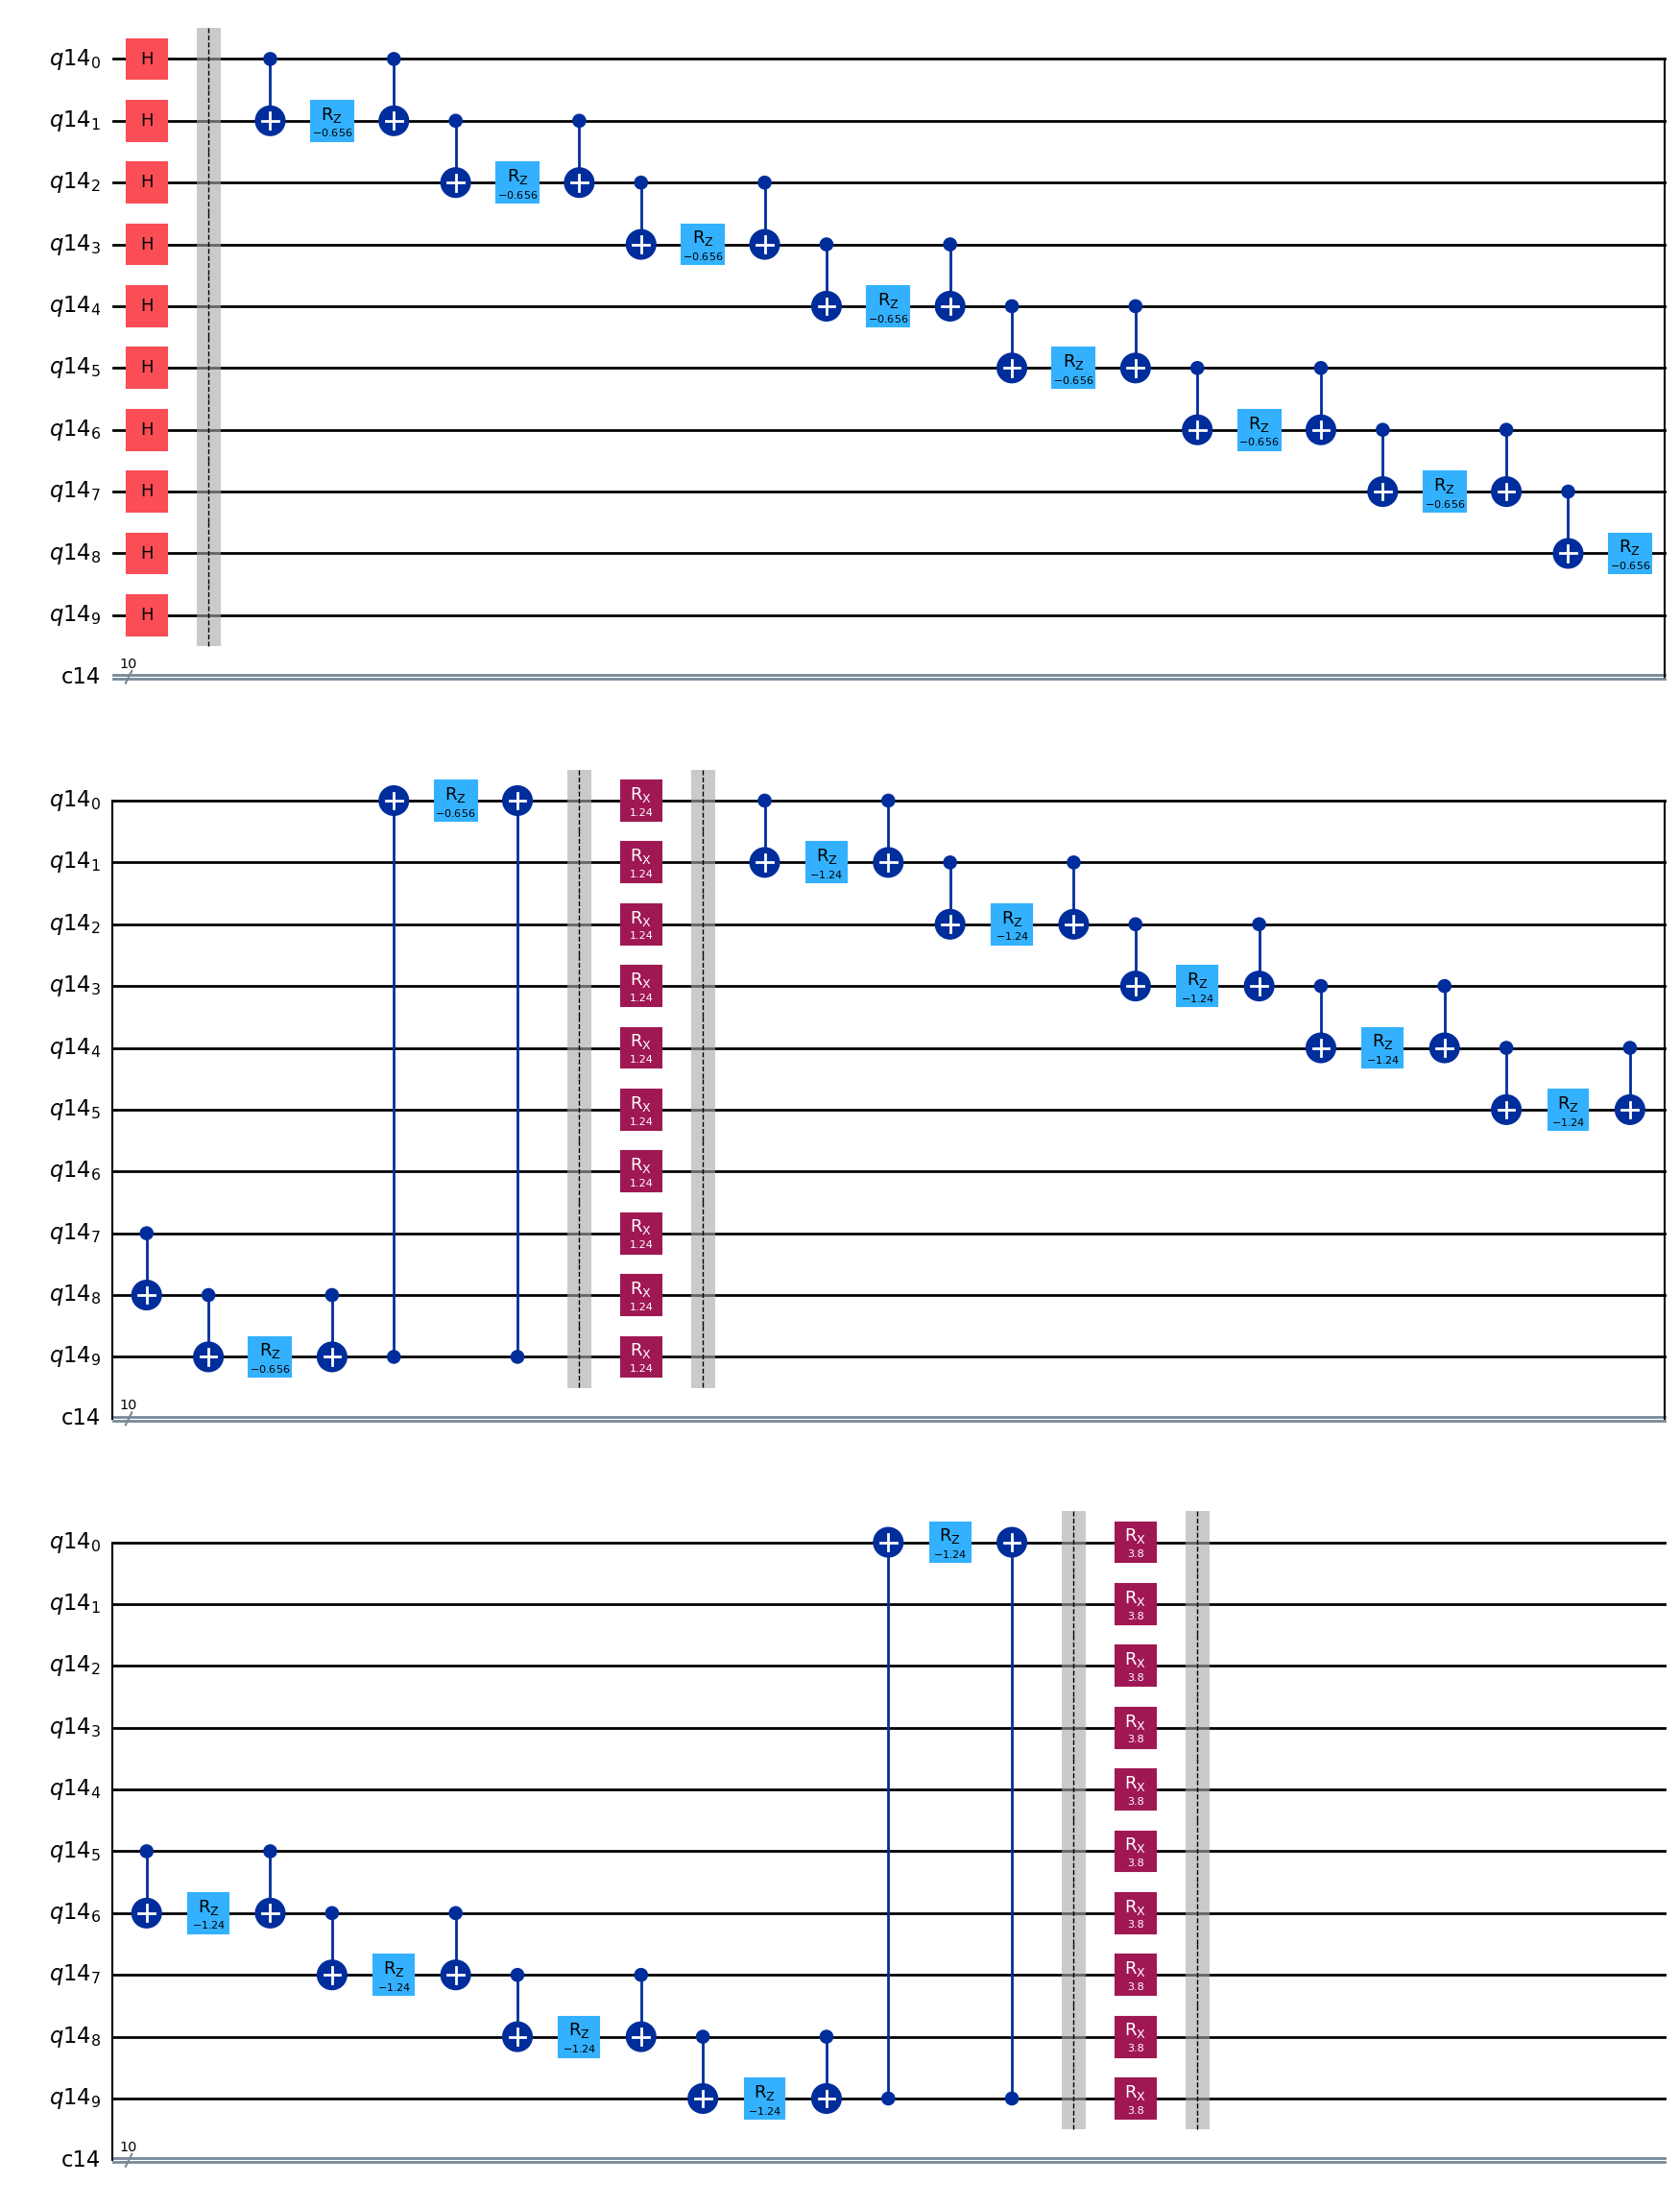

In [50]:

# Create the quantum circuit for C10, p=2

# Classical pre-optimal parameters for C10, p=2 (from the previous optimization step)
bestparams = [0.65588388, 1.24287264, 0.62143985, 1.8987511]  # g[0], g[1], b[0], b[1]

# create 10 quantum registers, one for each qubit
q = QuantumRegister(10)
# create 10 corresponding classical registers (needed for storing measurement results)
c=ClassicalRegister(10)
# create a quantum circuit with these registers
qaoa_qc = QuantumCircuit(q,c)

# Apply Hadamard gates to all qubits to create the initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10
edges_c10 = [(i, (i+1) % 10) for i in range(10)]
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])  # g[0] is the first parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B
for i in range(10):
    qaoa_qc.rx(2 * bestparams[2], q[i])  # b[0] is the second parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10 again (second layer)
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])  # g[1] is the third parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B again (second layer)
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])  # b[1] is the fourth parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Measure all qubits
# qaoa_qc.measure(q, c)

# Visualize the circuit
qaoa_qc.draw(output='mpl', style='iqx')


{'1010101010': 949, '0010010001': 2, '1010100110': 58, '1010011010': 48, '0100110101': 47, '1011001010': 42, '1001010110': 101, '1010110110': 85, '0100101010': 75, '1010100010': 12, '0101101001': 119, '0001101101': 3, '1010010010': 79, '0101010110': 50, '0010010101': 75, '0101010101': 941, '0110011101': 4, '0111010101': 4, '1010100100': 64, '0101011001': 45, '0101010010': 79, '1010110010': 70, '1100101010': 64, '1011001100': 1, '1001101010': 64, '1101010110': 86, '1010010110': 125, '0100101101': 101, '0110101010': 64, '1011010100': 116, '0010101001': 82, '1010101001': 54, '1101001010': 105, '0100010101': 12, '0101011010': 111, '0100101011': 99, '1011001001': 6, '1011011010': 82, '1100011010': 3, '1001011010': 92, '1101011010': 82, '0110101001': 114, '0100110001': 5, '0101011011': 76, '0100100101': 78, '0010110101': 112, '0101001011': 117, '0101001101': 63, '1010101101': 82, '0101101010': 99, '0010110011': 2, '0010101101': 99, '0110010101': 56, '0100101001': 78, '1011011110': 2, '100101

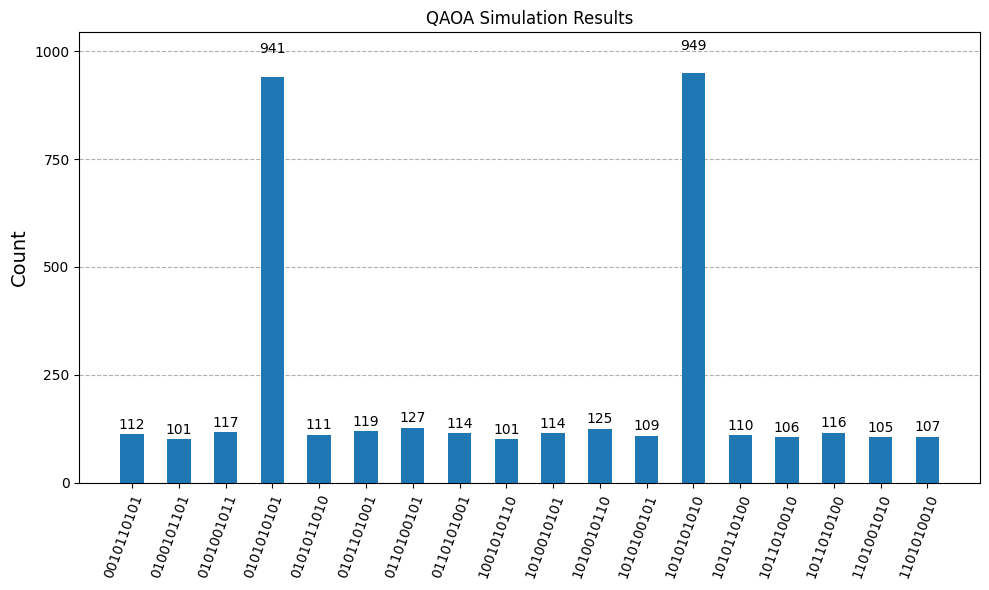

In [46]:

# ── Run simulation ───────────────────────────────────────────────

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_2 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_2.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_2, figsize=(10,6), title="QAOA Simulation Results")

### $C_{10}$ , p = 3

In [53]:

# Create the quantum circuit for C10, p=2

# Classical pre-optimal parameters for C10, p=2 (from the previous optimization step)
bestparams = [0.59174325, 1.15570715, 1.36422747, 2.2529987, 2.1487362, 1.86680204]  # g[0], g[1], g[2], b[0], b[1], b[2]

# create 10 quantum registers, one for each qubit
q = QuantumRegister(10)
# create 10 corresponding classical registers (needed for storing measurement results)
c=ClassicalRegister(10)
# create a quantum circuit with these registers
qaoa_qc = QuantumCircuit(q,c)

# Apply Hadamard gates to all qubits to create the initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10
edges_c10 = [(i, (i+1) % 10) for i in range(10)]
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])  # g[0] is the first parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])  # b[0] is the second parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10 again (second layer)
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])  # g[1] is the third parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B again (second layer)
for i in range(10):
    qaoa_qc.rx(2 * bestparams[4], q[i])  # b[1] is the fourth parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the problem unitary U_C for C10 again (third layer)
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[2], q[j])  # g[2] is the fifth parameter
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()  # Add a barrier for better visualization

# Apply the mixer unitary U_B again (third layer)
for i in range(10):
    qaoa_qc.rx(2 * bestparams[5], q[i])  # b[2] is the sixth parameter
qaoa_qc.barrier()  # Add a barrier for better visualization

# Measure all qubits
qaoa_qc.measure(q, c)

# Visualize the circuit
# qaoa_qc.draw(output='mpl', style='iqx')


{'0101010101': 1666, '0101011010': 84, '1010101010': 1607, '1010110101': 133, '0110101101': 130, '1001010010': 149, '0010100101': 136, '0010101001': 50, '1010010010': 50, '0010110101': 81, '0100101101': 94, '0101101011': 147, '1011010110': 123, '0110100101': 81, '0111100101': 1, '0010010101': 36, '1001011010': 80, '1101001010': 87, '1001001010': 38, '0100101001': 110, '0101101101': 51, '0101010010': 58, '1011001010': 27, '1010010100': 133, '0101010011': 31, '0110010011': 5, '0010101101': 88, '1001101010': 31, '0101001001': 50, '1010100100': 61, '1101101010': 53, '0101011011': 62, '1010101101': 55, '0110110101': 45, '1011010100': 98, '0110101010': 35, '1010010110': 89, '0100101010': 73, '1100101000': 1, '0101101010': 106, '1101010010': 93, '0100101011': 83, '1000100010': 1, '1010100110': 31, '0111010001': 2, '0110101011': 54, '0101001010': 116, '1010000101': 2, '0101011001': 28, '1010110100': 66, '1010100101': 68, '1001010110': 93, '0101001011': 74, '1011101000': 3, '1101011010': 136, '

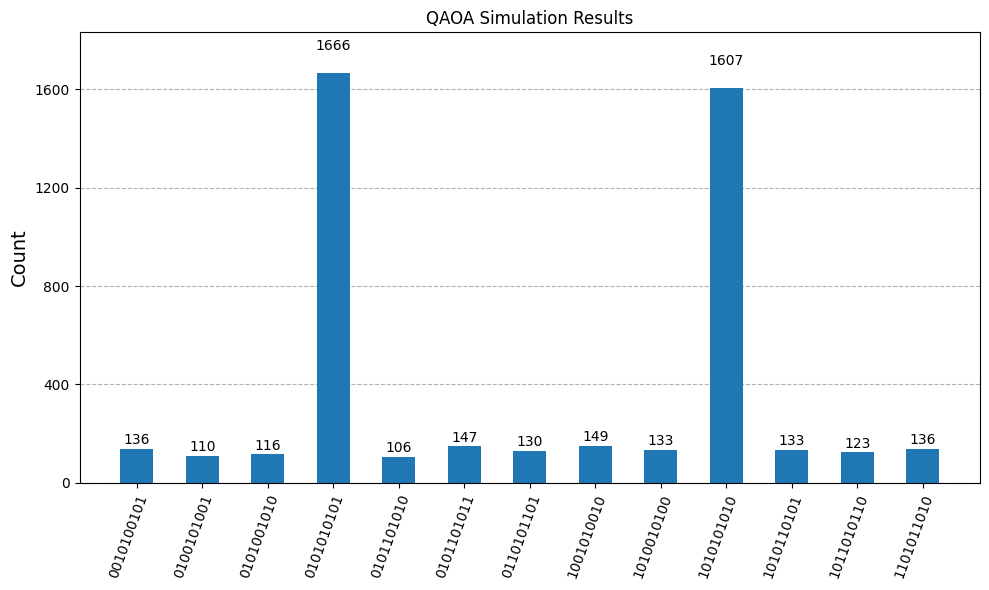

In [55]:

# ── Run simulation ───────────────────────────────────────────────

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_3 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_3.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_3, figsize=(10,6), title="QAOA Simulation Results")

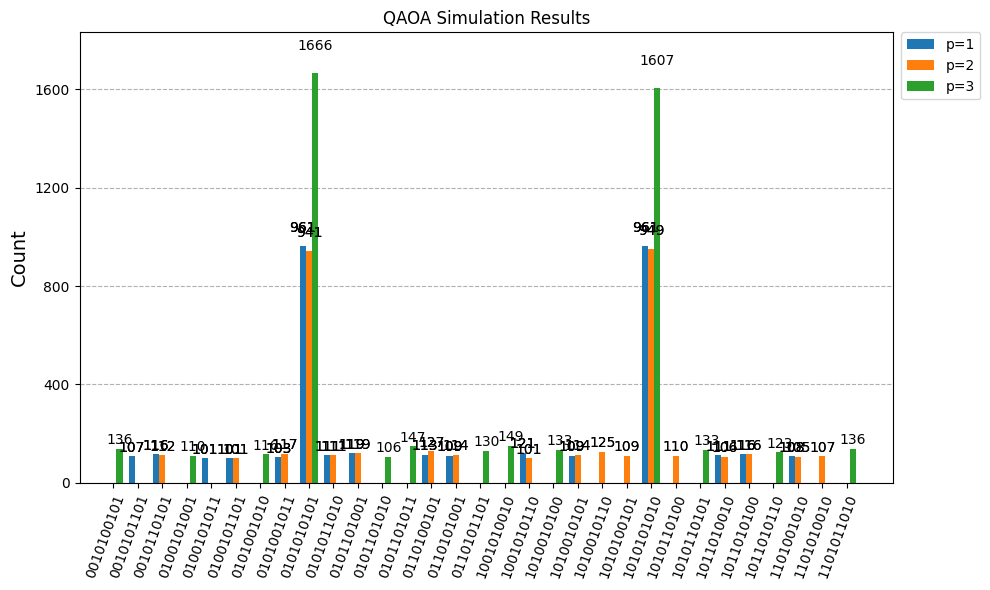

In [59]:
# Plot histogram of the results for p = 1,2,3

plot_histogram([filtered_counts_C10_1,filtered_counts_C10_2,filtered_counts_C10_3], figsize=(10,6), title="QAOA Simulation Results", legend=['p=1', 'p=2', 'p=3'])